# Baseline Analysis: Slice-Level and Phase-Level Performance

This notebook evaluates baseline segmentation performance at **slice level** for:
- `ACDC` (`Dataset200_ACDC`)
- `MM` (`Dataset300_MM`)

It computes per-slice Dice (foreground and per class), then compares:
1. **Slice-wise variation** (where in the stack performance drops)
2. **ED vs ES differences**


In [1]:
from pathlib import Path
import json
import re
import sys

import nibabel as nib
import numpy as np
import pandas as pd
import torch
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
import yaml

PROJECT_ROOT = Path('/mnt/hdd/ttoxopeus/basic_UNet')
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.models.unet import UNet


In [2]:
# ---------- Dataset / baseline configuration ----------
DATASET_CONFIGS = {
    'acdc': {
        'run_summary': Path('/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACDC/exp67_uniform_l1_acdc/baseline/evaluation/run_summary.json'),
        'images_ts': Path('/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset200_ACDC/imagesTs'),
        'labels_ts': Path('/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset200_ACDC/labelsTs'),
        'slice_axis': 2,
        'target_size': (256, 256),
        'num_classes': 4,
    },
    'mm': {
        'run_summary': Path('/mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACDC/exp74_uniform_l1_MM/baseline/evaluation/run_summary.json'),
        'images_ts': Path('/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset300_MM/imagesTs'),
        'labels_ts': Path('/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset300_MM/labelsTs'),
        'slice_axis': 2,
        'target_size': (256, 256),
        'num_classes': 4,
    },
}

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)


Device: cuda


In [3]:
# ---------- Helpers ----------

def unwrap_state_dict(obj):
    if isinstance(obj, dict):
        for k in ['state_dict', 'model_state_dict', 'net', 'model']:
            if k in obj and isinstance(obj[k], dict):
                return obj[k]
    return obj


def extract_case_phase(label_name: str):
    # e.g. patient101_ED.nii.gz -> case_id=patient101, phase=ED
    m = re.match(r'(.+?)_(ED|ES)\.nii\.gz$', label_name)
    if m:
        return m.group(1), m.group(2)
    return label_name.replace('.nii.gz', ''), 'Unknown'


def collect_pairs(images_ts: Path, labels_ts: Path):
    lbl_paths = sorted(labels_ts.glob('*.nii.gz'))
    pairs = []
    for lp in lbl_paths:
        img_name = lp.name.replace('.nii.gz', '_0000.nii.gz')
        ip = images_ts / img_name
        if not ip.exists():
            raise FileNotFoundError(f'Missing image for label: {lp} -> expected {ip}')
        pairs.append((ip, lp))
    return pairs


def preprocess_image_slice(img_np: np.ndarray, target_size=(256, 256), normalize=True):
    # same spirit as training data loader: percentile clip + min-max normalize + resize
    if normalize:
        img_np = np.clip(img_np, np.percentile(img_np, 1), np.percentile(img_np, 99))
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

    img_t = torch.from_numpy(img_np).float().unsqueeze(0)  # [1,H,W]
    img_t = TF.resize(img_t, target_size, antialias=True)  # [1,H,W]
    return img_t


def preprocess_label_slice(lbl_np: np.ndarray, target_size=(256, 256)):
    lbl_t = torch.from_numpy(lbl_np).long()  # [H,W]
    lbl_t = TF.resize(
        lbl_t.unsqueeze(0).float(),
        target_size,
        interpolation=TF.InterpolationMode.NEAREST,
    ).squeeze(0).long()
    return lbl_t


def dice_binary(pred_mask: np.ndarray, gt_mask: np.ndarray, eps=1e-6):
    inter = np.logical_and(pred_mask, gt_mask).sum()
    union = pred_mask.sum() + gt_mask.sum()
    return (2.0 * inter + eps) / (union + eps)


def dice_per_class(pred_lbl: np.ndarray, gt_lbl: np.ndarray, num_classes=4):
    out = {}
    for c in range(num_classes):
        out[c] = float(dice_binary(pred_lbl == c, gt_lbl == c))
    return out


def load_model_from_run_summary(run_summary_path: Path, device: torch.device):
    rs = json.loads(run_summary_path.read_text())
    ckpt_path = Path(rs['eval']['checkpoint'])

    # load features/in/out from baseline config in same experiment root
    cfg_path = run_summary_path.parents[1] / 'config.yaml'  # .../baseline/config.yaml
    cfg = yaml.safe_load(cfg_path.read_text())
    model_cfg = cfg['train']['model']

    model = UNet(
        in_ch=int(model_cfg['in_channels']),
        out_ch=int(model_cfg['out_channels']),
        enc_features=tuple(model_cfg['features']),
    ).to(device)

    obj = torch.load(ckpt_path, map_location=device)
    sd = unwrap_state_dict(obj)
    model.load_state_dict(sd)
    model.eval()

    return model, ckpt_path


In [ ]:
# ---------- Slice-level evaluation ----------
@torch.no_grad()
def evaluate_dataset_slice_level(name: str, cfg: dict, device: torch.device):
    model, ckpt_path = load_model_from_run_summary(cfg['run_summary'], device)
    pairs = collect_pairs(cfg['images_ts'], cfg['labels_ts'])

    rows = []
    for img_path, lbl_path in pairs:
        case_id, phase = extract_case_phase(lbl_path.name)

        img_vol = nib.load(str(img_path)).get_fdata()
        lbl_vol = nib.load(str(lbl_path)).get_fdata()

        axis = int(cfg.get('slice_axis', 2))
        n_slices = int(lbl_vol.shape[axis])

        for s in range(n_slices):
            img_slice = np.take(img_vol, s, axis=axis)
            lbl_slice = np.take(lbl_vol, s, axis=axis).astype(np.int64)

            x = preprocess_image_slice(img_slice, target_size=cfg['target_size'], normalize=True)
            y = preprocess_label_slice(lbl_slice, target_size=cfg['target_size'])

            logits = model(x.unsqueeze(0).to(device))  # [1,C,H,W]
            pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
            gt = y.cpu().numpy()

            d = dice_per_class(pred, gt, num_classes=cfg['num_classes'])
            dice_fg = float(np.mean([d[c] for c in range(1, cfg['num_classes'])]))
            dice_all = float(np.mean([d[c] for c in range(cfg['num_classes'])]))

            rows.append({
                'dataset': name,
                'case_id': case_id,
                'phase': phase,
                'slice_idx': s,
                'num_slices': n_slices,
                'slice_pos': s / max(1, n_slices - 1),
                'dice_fg': dice_fg,
                'dice_all': dice_all,
                'dice_bg': d[0],
                'dice_c1': d[1],
                'dice_c2': d[2],
                'dice_c3': d[3],
                'gt_fg_pixels': int((gt > 0).sum()),
                'img_path': str(img_path),
                'lbl_path': str(lbl_path),
            })

    df = pd.DataFrame(rows)
    print(f'[{name}] checkpoint: {ckpt_path}')
    print(f'[{name}] rows (slices): {len(df)} | cases: {df.case_id.nunique()} | phases: {sorted(df.phase.unique().tolist())}')
    return df


df_acdc = evaluate_dataset_slice_level('acdc', DATASET_CONFIGS['acdc'], DEVICE)
df_mm = evaluate_dataset_slice_level('mm', DATASET_CONFIGS['mm'], DEVICE)

df = pd.concat([df_acdc, df_mm], ignore_index=True)
print('Combined shape:', df.shape)
df.head()


[acdc] checkpoint: /mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACDC/exp67_uniform_l1_acdc/baseline/training/final_model.pth
[acdc] rows (slices): 1076 | cases: 50 | phases: ['ED', 'ES']
[mm] checkpoint: /mnt/hdd/ttoxopeus/basic_UNet/results/UNet_ACDC/exp74_uniform_l1_MM/baseline/training/final_model.pth
[mm] rows (slices): 806 | cases: 34 | phases: ['ED', 'ES']
Combined shape: (1882, 15)


,dataset,case_id,phase,slice_idx,num_slices,slice_pos,dice_fg,dice_all,dice_bg,dice_c1,dice_c2,dice_c3,gt_fg_pixels,img_path,lbl_path
0,acdc,patient101,ED,0,10,0.000000,9.579341e-01,0.968326,0.999501,1.000000e+00,8.969578e-01,9.768444e-01,1460,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
1,acdc,patient101,ED,1,10,0.111111,9.558172e-01,0.966737,0.999497,9.816887e-01,9.100946e-01,9.756681e-01,2860,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
2,acdc,patient101,ED,2,10,0.222222,9.499780e-01,0.962298,0.999257,9.758025e-01,8.940092e-01,9.801223e-01,2974,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
3,acdc,patient101,ED,3,10,0.333333,9.500395e-01,0.962307,0.999108,9.691161e-01,9.015152e-01,9.794872e-01,2763,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
4,acdc,patient101,ED,4,10,0.444444,9.455570e-01,0.958973,0.999221,9.647059e-01,8.980892e-01,9.738758e-01,2591,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1877,mm,patient134,ES,9,14,0.692308,9.112922e-01,0.933187,0.998872,9.085072e-01,9.347918e-01,8.905775e-01,2110,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
1878,mm,patient134,ES,10,14,0.769231,6.202958e-01,0.714161,0.995757,2.159827e-09,9.367681e-01,9.241192e-01,1882,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
1879,mm,patient134,ES,11,14,0.846154,1.000000e+00,1.000000,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,0,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...
1880,mm,patient134,ES,12,14,0.923077,4.318385e-09,0.246338,0.985354,7.974482e-10,1.848429e-09,1.030928e-08,0,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...,/mnt/hdd/ttoxopeus/datasets/nnUNet_raw/Dataset...


In [ ]:
df

In [5]:
# ---------- Summary tables ----------
summary_phase = (
    df.groupby(['dataset', 'phase'])['dice_fg']
      .agg(['count', 'mean', 'std', 'median'])
      .reset_index()
      .sort_values(['dataset', 'phase'])
)
summary_dataset = (
    df.groupby(['dataset'])['dice_fg']
      .agg(['count', 'mean', 'std', 'median'])
      .reset_index()
)

print('By dataset')
display(summary_dataset)
print('By dataset + phase')
display(summary_phase)


By dataset


,dataset,count,mean,std,median
0,acdc,1076,0.855954,0.171193,0.923784
1,mm,806,0.785430,0.229697,0.887917


By dataset + phase


,dataset,phase,count,mean,std,median
0,acdc,ED,538,0.876278,0.153512,0.930957
1,acdc,ES,538,0.835630,0.185134,0.915149
2,mm,ED,403,0.807650,0.213452,0.895875
3,mm,ES,403,0.763211,0.243106,0.881709


/media/ttoxopeus/tmp/ipykernel_807007/1581872195.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(vals, labels=phases, showfliers=False)
/media/ttoxopeus/tmp/ipykernel_807007/1581872195.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(vals, labels=phases, showfliers=False)


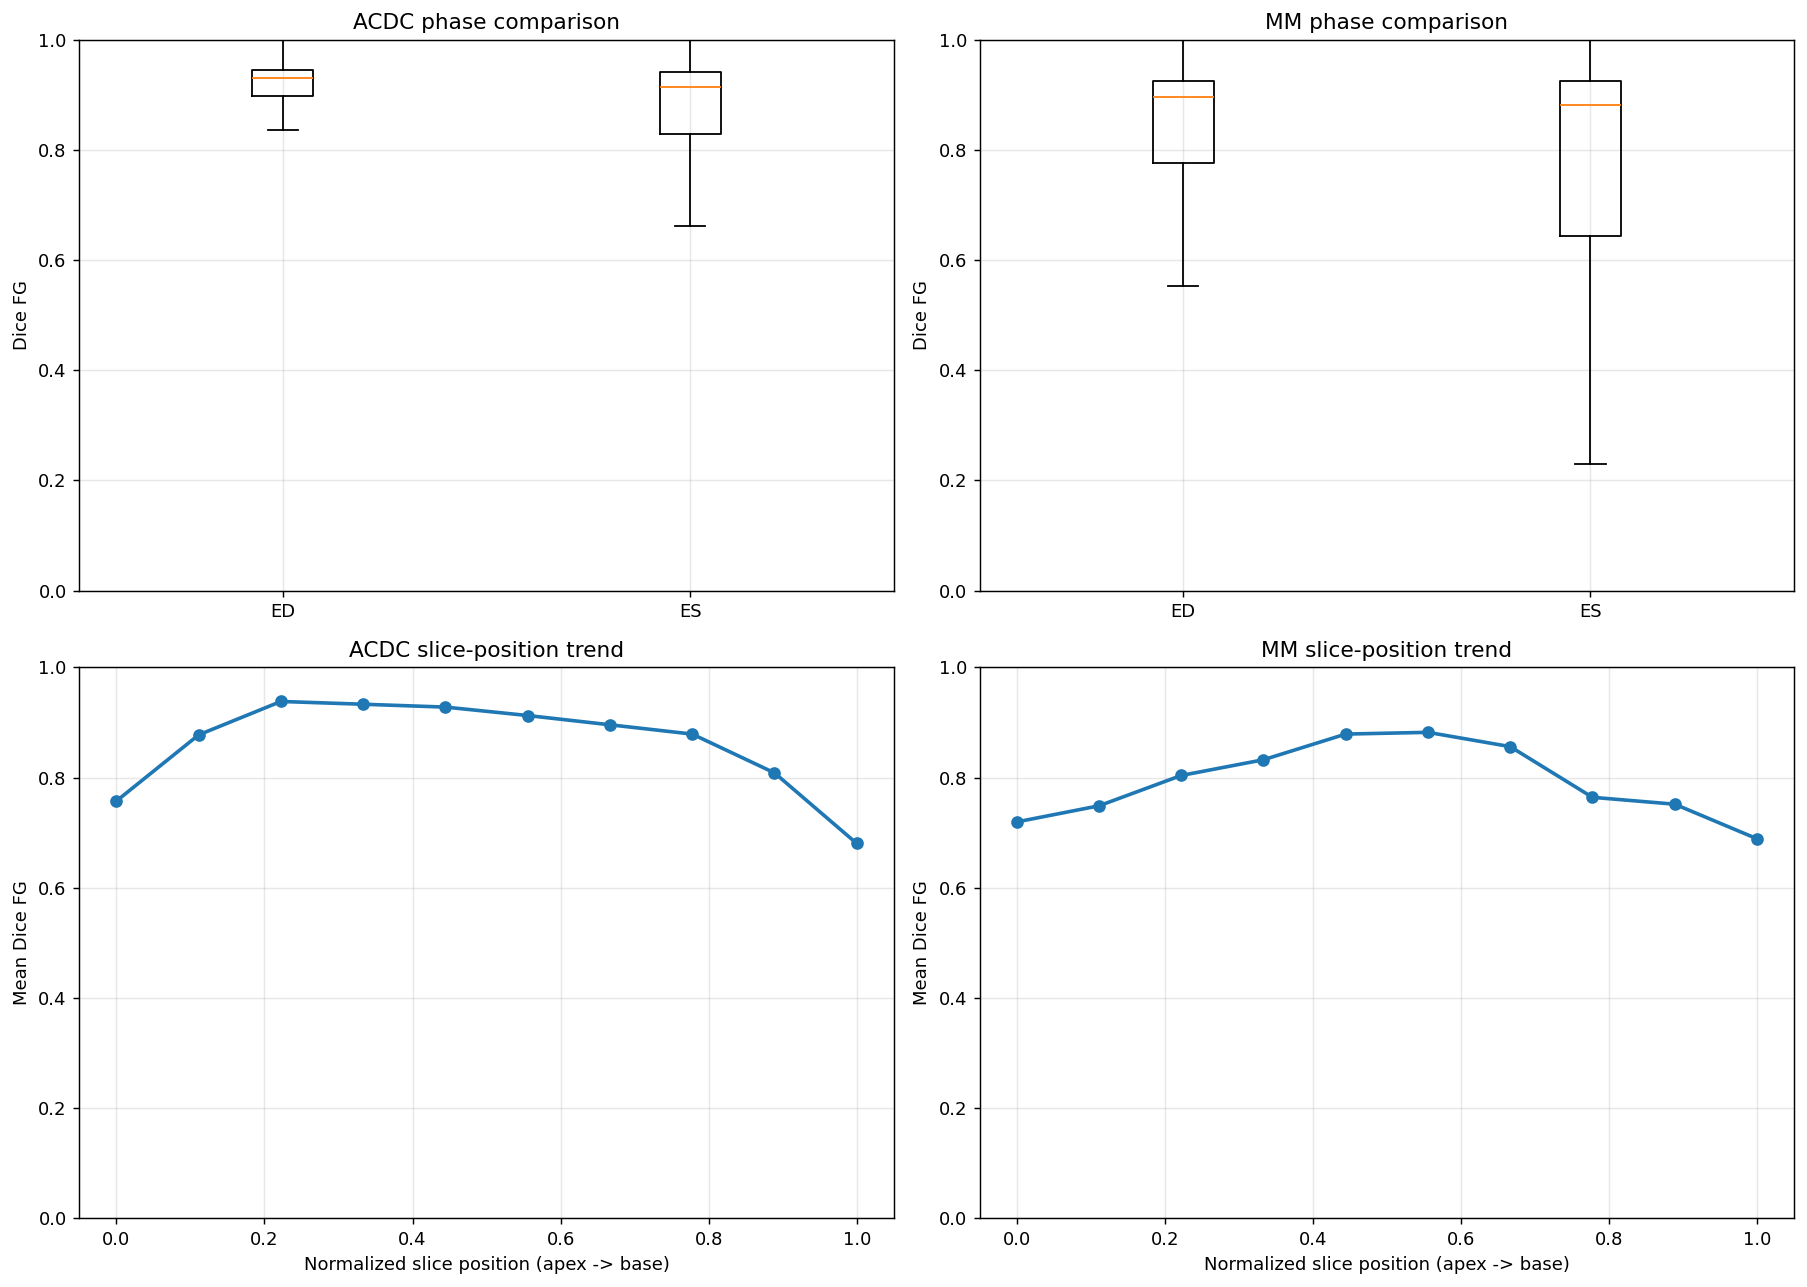

In [6]:
# ---------- Plots: ED vs ES and slice-position effects ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=130)

# 1) ED vs ES boxplots per dataset
for col, ds in enumerate(['acdc', 'mm']):
    ax = axes[0, col]
    dsub = df[df['dataset'] == ds]
    phases = ['ED', 'ES']
    vals = [dsub[dsub['phase'] == ph]['dice_fg'].values for ph in phases]
    ax.boxplot(vals, labels=phases, showfliers=False)
    ax.set_title(f'{ds.upper()} phase comparison')
    ax.set_ylabel('Dice FG')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

# 2) Slice-position trend (binned)
bins = np.linspace(0, 1, 11)
for col, ds in enumerate(['acdc', 'mm']):
    ax = axes[1, col]
    dsub = df[df['dataset'] == ds].copy()
    dsub['slice_bin'] = pd.cut(dsub['slice_pos'], bins=bins, include_lowest=True)
    curve = dsub.groupby('slice_bin', observed=False)['dice_fg'].mean()
    centers = np.arange(len(curve)) / (len(curve) - 1)
    ax.plot(centers, curve.values, marker='o', linewidth=2)
    ax.set_title(f'{ds.upper()} slice-position trend')
    ax.set_xlabel('Normalized slice position (apex -> base)')
    ax.set_ylabel('Mean Dice FG')
    ax.set_ylim(0, 1)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Optional: save slice-level dataframe for later analyses
OUT_CSV = PROJECT_ROOT / 'results' / 'baseline_slice_level_metrics_acdc_mm.csv'
OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_CSV, index=False)
print('Saved:', OUT_CSV)
